In [1]:
import os
import shutil
import Bio.PDB
from Bio.PDB import PDBParser, PDBIO, Select, Superimposer, Structure, Model, Chain, Residue, Atom
import matplotlib.pyplot as plt
from collections import Counter
from scipy.spatial.distance import cdist

import numpy as np
import pandas as pd

In [ ]:
# 在一个pdb内，计算两条链之间所有原子对的距离，并输出最小距离

def calculate_distance(pdb_file, chain_id_1, chain_id_2):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('sample', pdb_file)
    model = structure[0]
    
    chain1_atoms = []
    chain1_idxs = []
    chain2_atoms = []
    chain2_idxs = []
    for chain in model:
        if chain.get_id() == chain_id_1:
            for residue in chain:
                for i, atom in enumerate(residue):
                    if atom.get_name() in ['N', 'CA', 'C', 'O']:
                        chain1_atoms.append(atom.get_coord())
                        chain1_idxs.append((residue.get_id()[1], atom.get_name())) # 记录残基号和原子名
        elif chain.get_id() == chain_id_2:
            for residue in chain:
                for atom in residue:
                    if atom.get_name() in ['N', 'CA', 'C', 'O']:
                        chain2_atoms.append(atom.get_coord())
                        chain2_idxs.append((residue.get_id()[1], atom.get_name()))
    
    if not chain1_atoms or not chain2_atoms:
        return None  # 如果任一链没有原子，返回None
    
    distance_matrix = cdist(chain1_atoms, chain2_atoms)

    # 同时给出索引矩阵，每个矩阵元记录对应的原子对的残基号和原子名
    # 构建索引矩阵，记录每个距离对应的原子对信息
    index_matrix = []
    for idx1 in chain1_idxs:
        row = []
        for idx2 in chain2_idxs:
            row.append((idx1, idx2))
        index_matrix.append(row)
    # index_matrix[i][j] 对应 distances[i, j] 的原子对 (chain1, chain2)
    
    return distance_matrix, index_matrix

def count_close_contacts_func(distance_matrix, index_matrix, rad_O=1.6, rad_N=1.6, rad_C=2.1, vdw_scale=0.7):
    count = 0
    for i in range(distance_matrix.shape[0]):
        for j in range(distance_matrix.shape[1]):
            atom1_info = index_matrix[i][j][0]
            atom2_info = index_matrix[i][j][1]
            # 根据原子名确定范德华半径
            if atom1_info[1] == 'O':
                r1 = rad_O
            elif atom1_info[1] == 'N':
                r1 = rad_N
            else:
                r1 = rad_C
            if atom2_info[1] == 'O':
                r2 = rad_O
            elif atom2_info[1] == 'N':
                r2 = rad_N
            else:
                r2 = rad_C
            if distance_matrix[i, j] < vdw_scale * (r1 + r2):
                count += 1
    return count

output_with_target_dir = "dimer"
pdbs = os.listdir(output_with_target_dir)

binder_chain = 'L'
ideal_pdb = []
for pdb in pdbs:
    if pdb.endswith('.pdb'):
        with open(os.path.join(output_with_target_dir, pdb), 'r') as f:
            lines = f.readlines()
            chain_ids = set()
            for line in lines:
                if line.startswith(('ATOM', 'HETATM')):
                    chain_ids.add(line[21])
            target_chain = next((c_id for c_id in chain_ids if c_id != binder_chain), None)
            if target_chain is None:
                continue

        pdb_file = os.path.join(output_with_target_dir, pdb)
        d, idx_matrix= calculate_distance(pdb_file, target_chain, binder_chain)
        min_distance = np.min(d)
        min_index = np.unravel_index(np.argmin(d), d.shape)
        atom1_info = idx_matrix[min_index[0]][min_index[1]][0] # 输出(residue_number, atom_name)
        atom2_info = idx_matrix[min_index[0]][min_index[1]][1]
        # print(f"Minimum distance: {min_distance:.2f} Å between Chain {target_chain} Residue {atom1_info[0]} Atom {atom1_info[1]} and Chain {binder_chain} Residue {atom2_info[0]} Atom {atom2_info[1]}")

        # 按照距离矩阵以及索引矩阵，计算距离小于原子范德华半径之和的原子对数目
        count_close_contacts = count_close_contacts_func(d, idx_matrix)
        # print(f"Number of close contacts (distance < sum of VdW radii): {count_close_contacts}")

        if count_close_contacts == 0:
            ideal_pdb.append(pdb) # 保存target与binder之间没有冲突的pdb

# for i in ideal_pdb:
#     print(i)
print(len(ideal_pdb))


146


In [4]:
# 尝试不同的vdw_scale参数，绘制折线图，横坐标为vdw_scale，纵坐标为没有close contact的pdb数量
vdw_scales = np.arange(0.5, 1.1, 0.1)
counts = []
for vdw_scale in vdw_scales:
    count_no_clash = 0
    for pdb in pdbs:
        if pdb.endswith('.pdb'):
            with open(os.path.join(output_with_target_dir, pdb), 'r') as f:
                lines = f.readlines()
                for line in lines:
                    if line.startswith(('ATOM', 'HETATM')) and line[21] != binder_chain:
                        target_chain = line[21]
                        break
                if target_chain is None:
                    continue

            pdb_file = os.path.join(output_with_target_dir, pdb)
            d, idx_matrix= calculate_distance(pdb_file, target_chain, binder_chain)
            count_close_contacts = count_close_contacts_func(d, idx_matrix, vdw_scale=vdw_scale)
            if count_close_contacts == 0:
                count_no_clash += 1
    counts.append(count_no_clash/170)



In [6]:
print(counts)

[0.9941176470588236, 0.9823529411764705, 0.8588235294117647, 0.27647058823529413, 0.029411764705882353, 0.011764705882352941, 0.0]


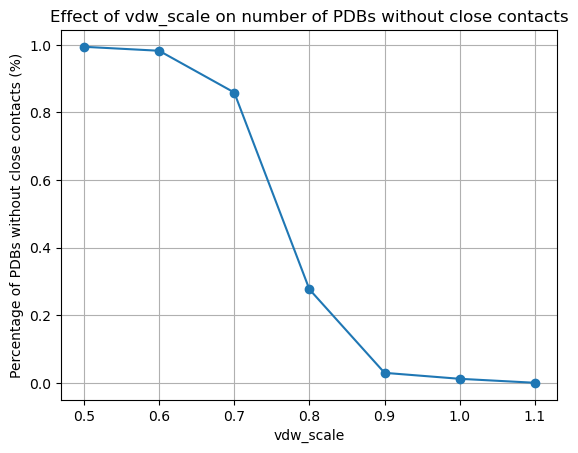

In [5]:
plt.plot(vdw_scales, counts, marker='o')
plt.xlabel('vdw_scale')
plt.ylabel('Percentage of PDBs without close contacts (%)')
plt.title('Effect of vdw_scale on number of PDBs without close contacts')
plt.grid()
plt.show()